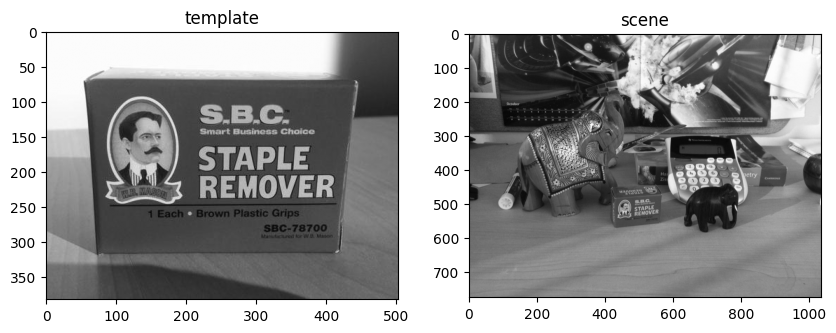

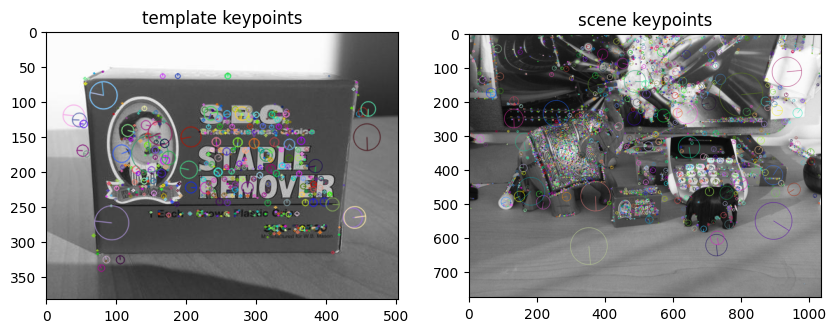

703
(703, 128)
Good matches: 103


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# load images
box_image = cv2.imread("../Datasets/ImagesObjectDetection/stapleRemover.jpg", cv2.IMREAD_GRAYSCALE)
scene_image = cv2.imread("../Datasets/ImagesObjectDetection/clutteredDesk.jpg", cv2.IMREAD_GRAYSCALE)

# display images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(box_image, cmap="gray")
plt.title("template")

plt.subplot(1, 2, 2)
plt.imshow(scene_image, cmap="gray")
plt.title("scene")
plt.show()

# initialize SIFT detector
sift = cv2.SIFT_create()

# detect keypoints and compute descriptors
box_keypoints, box_descriptors = sift.detectAndCompute(box_image, None)
scene_keypoints, scene_descriptors = sift.detectAndCompute(scene_image, None)

# draw keypoints
box_keypoints_image = cv2.drawKeypoints(
    box_image,
    box_keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

scene_keypoints_image = cv2.drawKeypoints(
    scene_image,
    scene_keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(box_keypoints_image, cmap="gray")
plt.title("template keypoints")

plt.subplot(1, 2, 2)
plt.imshow(scene_keypoints_image, cmap="gray")
plt.title("scene keypoints")
plt.show()

# inspect features
print(len(box_keypoints))
print(box_descriptors.shape)

# matching
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)

flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(box_descriptors, scene_descriptors, k=2)

# apply Lowe's ratio test
good_matches = []
for m, n in matches:
    if m.distance < 0.7 * n.distance:
        good_matches.append(m)

print("Good matches:", len(good_matches))

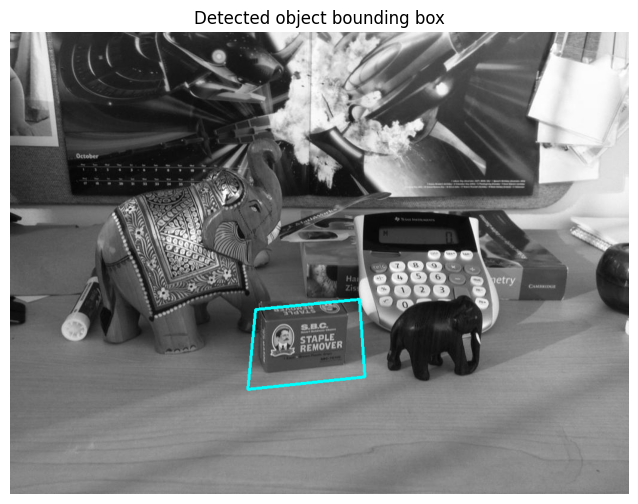

array([[ 3.71249392e-01, -1.48655267e-01,  4.11237067e+02],
       [-1.26269175e-02,  1.77519919e-01,  4.65026410e+02],
       [ 4.28041377e-05, -2.88935438e-04,  1.00000000e+00]])

In [2]:
if len(good_matches) > 10:

    # Source and destination points
    src_pts = np.float32(
        [box_keypoints[m.queryIdx].pt for m in good_matches]
    ).reshape(-1, 1, 2)

    dst_pts = np.float32(
        [scene_keypoints[m.trainIdx].pt for m in good_matches]
    ).reshape(-1, 1, 2)


    # Homography with RANSAC
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)


    # Bounding box drawing
    h, w = box_image.shape

    box_corners = np.float32([
        [0, 0],
        [w, 0],
        [w, h],
        [0, h]
    ]).reshape(-1, 1, 2)

    transformed_corners = cv2.perspectiveTransform(box_corners, H)

    # Convert to color for drawing
    scene_image_color = cv2.cvtColor(scene_image, cv2.COLOR_GRAY2BGR)

    # Draw lines between corners
    for i in range(len(transformed_corners) - 1):
        pt1 = tuple(np.int32(transformed_corners[i][0]))
        pt2 = tuple(np.int32(transformed_corners[i + 1][0]))

        cv2.line(scene_image_color, pt1, pt2, (0, 255, 255), 3)

    # Close the box (last → first)
    pt1 = tuple(np.int32(transformed_corners[-1][0]))
    pt2 = tuple(np.int32(transformed_corners[0][0]))
    cv2.line(scene_image_color, pt1, pt2, (0, 255, 255), 3)

    # Display result
    plt.figure(figsize=(8, 6))
    plt.imshow(scene_image_color)
    plt.title("Detected object bounding box")
    plt.axis("off")
    plt.show()
H

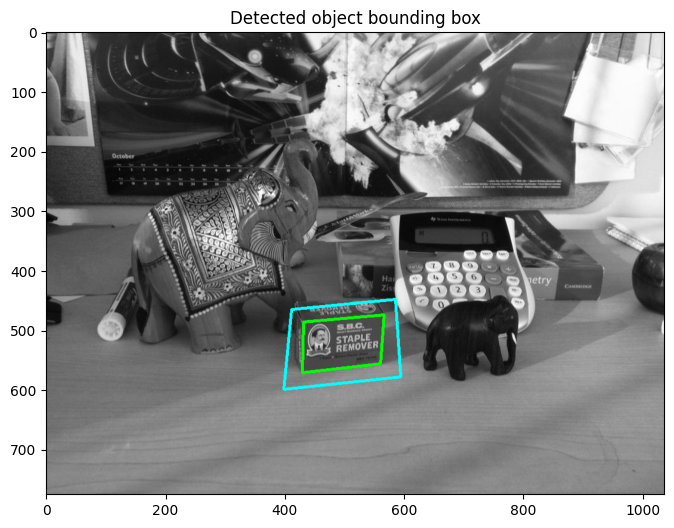

In [3]:
# Manually defined box corners (NOT from image size)
my_box_corners = np.float32([
    [63, 73],
    [444, 77],
    [418, 316],
    [75, 319],
    [63, 73]   # closing point
]).reshape(-1, 1, 2)

# Transform using homography
transformed_corners = cv2.perspectiveTransform(my_box_corners, H)

# Draw lines
for i in range(len(transformed_corners) - 1):
    pt1 = tuple(np.int32(transformed_corners[i][0]))
    pt2 = tuple(np.int32(transformed_corners[i + 1][0]))

    cv2.line(scene_image_color, pt1, pt2, (0, 255, 0), 3)

# Display
plt.figure(figsize=(8, 6))
plt.imshow(scene_image_color)
plt.title("Detected object bounding box")
plt.show()